<a href="https://colab.research.google.com/github/trialdyk/marchine-learning/blob/main/JS06/Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab JS06 - Klasifikasi Citra Siang dan Malam dengan SVM (Kernel RBF + Fitur Histogram)


## Langkah 0 - Persiapan Dataset, Import Library, dan Konfigurasi

In [1]:
!curl -s -L -A "Mozilla/5.0" "https://1812311909-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2FYHOv2XH8FJMJSMsnhwNa%2Fuploads%2F9IvI7imHRxFYT9gtRGh7%2Fimages.zip?alt=media&token=d1bc0a22-4056-4a11-a801-04f245ee0e62" -o images.zip
!unzip -q -o images.zip

In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
train_dir = 'images/training/'
test_dir = 'images/test/'

## Langkah 1 - Load Data

Fungsi `load_dataset` sama dengan praktikum, hanya label diambil dari `dir.name` agar aman di Windows maupun Linux.
Data `training` dan `test` bawaan praktikum **digabung** terlebih dahulu, lalu dibagi ulang dengan rasio 80:20 sesuai soal.

In [3]:
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []

    for d in sorted(p.glob('*')):
        if not d.is_dir():
            continue
        label = d.name  # 'day' atau 'night'
        for file in sorted(d.glob('*.jpg')):
            img = mpimg.imread(file)
            if img is not None:
                img_list.append((img, label))

    return img_list


img_all = load_dataset(train_dir) + load_dataset(test_dir)
print(f'Total gambar: {len(img_all)}')
print(pd.Series([l for _, l in img_all]).value_counts())

Total gambar: 400
day      200
night    200
Name: count, dtype: int64


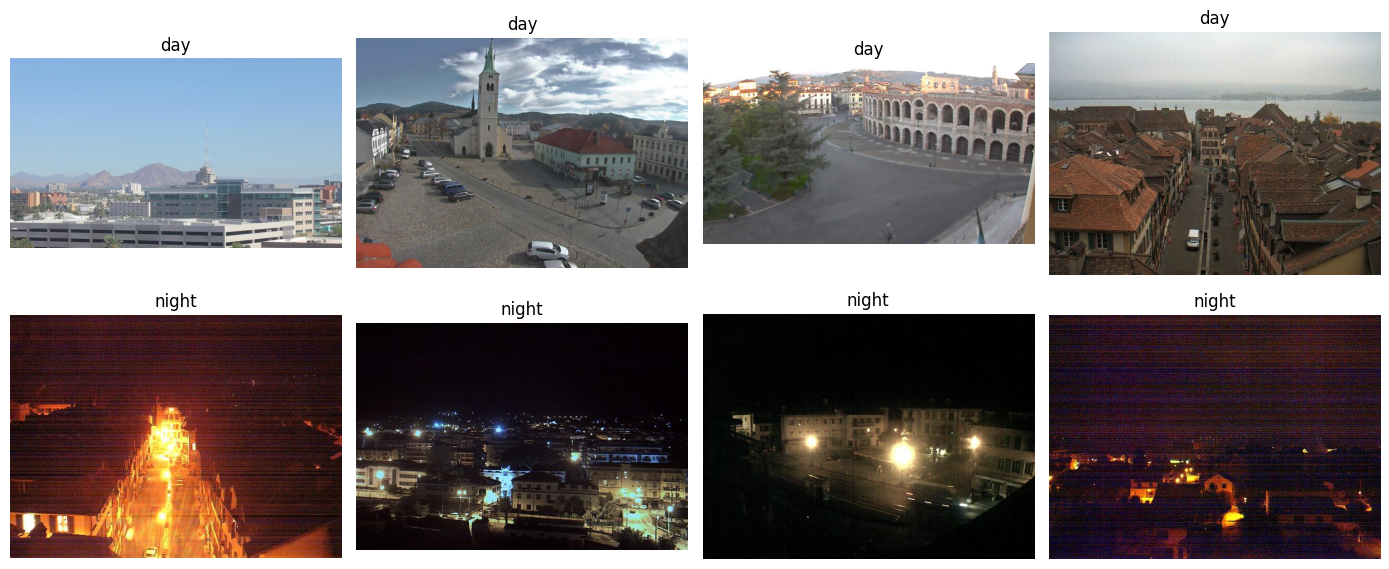

In [4]:
# Inspeksi visual acak
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
rng = np.random.default_rng(RANDOM_STATE)
for ax, label in zip(axes.ravel(), ['day'] * 4 + ['night'] * 4):
    pool = [im for im, l in img_all if l == label]
    ax.imshow(pool[rng.integers(len(pool))])
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Langkah 2 - Pra Pengolahan Data

Ukuran gambar distandarkan ke 1100x600 dan label di-*encode* (day = 1, night = 0), sama seperti praktikum.

In [5]:
def standarized_input(image):
    return cv2.resize(image, (1100, 600))


def label_encoder(label):
    return 1 if label == 'day' else 0


def preprocess(img_list):
    return [(standarized_input(img), label_encoder(label)) for img, label in img_list]


std_all = preprocess(img_all)
print(std_all[0][0].shape, std_all[0][1])

(600, 1100, 3) 1


## Langkah 3 - Ekstraksi Fitur Histogram

Gambar diubah ke ruang warna **HSV**, lalu dihitung histogram tiap kanal:

| Kanal | Bin | Keterangan |
|---|---|---|
| H (Hue) | 16 | corak warna |
| S (Saturation) | 16 | kejenuhan warna |
| V (Value) | 32 | tingkat kecerahan (paling relevan untuk siang vs malam) |

Tiap histogram dinormalisasi (jumlah = 1) agar tidak bergantung pada ukuran gambar. Hasil akhir: **64 fitur per gambar**.

In [6]:
def hsv_histogram(image, bins=(16, 16, 32)):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ranges = [180, 256, 256]  # rentang nilai H, S, V di OpenCV
    feats = []
    for ch, (b, r) in enumerate(zip(bins, ranges)):
        h = cv2.calcHist([hsv], [ch], None, [b], [0, r]).ravel()
        feats.append(h / h.sum())
    return np.concatenate(feats)


def extract_features(img_list, fn=hsv_histogram):
    X = np.array([fn(img) for img, _ in img_list])
    y = np.array([label for _, label in img_list])
    return X, y


X, y = extract_features(std_all)
print(f'Dimensi fitur: {X.shape}')
print(f'Distribusi label: {np.bincount(y)} (0 = night, 1 = day)')

Dimensi fitur: (400, 64)
Distribusi label: [200 200] (0 = night, 1 = day)


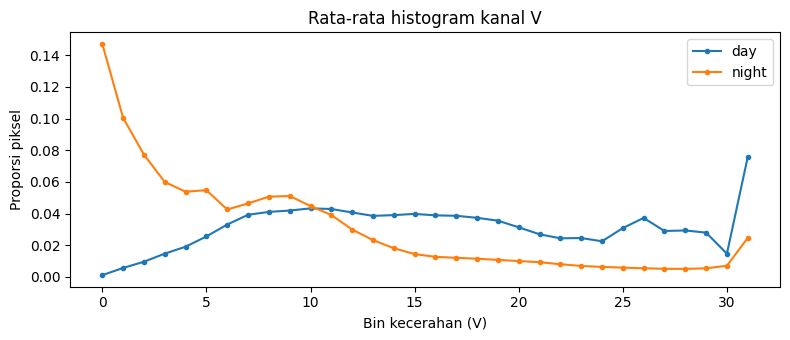

In [7]:
# Rata-rata histogram kanal V: siang vs malam
v_day = X[y == 1][:, 32:].mean(axis=0)
v_night = X[y == 0][:, 32:].mean(axis=0)

plt.figure(figsize=(8, 3.5))
plt.plot(v_day, label='day', marker='o', ms=3)
plt.plot(v_night, label='night', marker='o', ms=3)
plt.xlabel('Bin kecerahan (V)')
plt.ylabel('Proporsi piksel')
plt.title('Rata-rata histogram kanal V')
plt.legend()
plt.tight_layout()
plt.show()

## Langkah 4 - Split Data 80:20

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Distribusi train: {np.bincount(y_train)} | test: {np.bincount(y_test)}')

Train: (320, 64), Test: (80, 64)
Distribusi train: [160 160] | test: [40 40]


## Langkah 5 - Baseline SVM RBF (parameter bawaan)

In [9]:
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf')),  # C=1, gamma='scale'
])
baseline.fit(X_train, y_train)

acc_base_train = accuracy_score(y_train, baseline.predict(X_train))
acc_base_test = accuracy_score(y_test, baseline.predict(X_test))
print(f'Baseline  | Train: {acc_base_train:.4f} | Test: {acc_base_test:.4f}')

Baseline  | Train: 1.0000 | Test: 1.0000


## Langkah 6 - Hyperparameter Tuning Kernel RBF

Parameter yang dituning:
- `C` : penalti kesalahan klasifikasi (semakin besar, margin makin ketat).
- `gamma` : jangkauan pengaruh satu sampel (semakin besar, batas keputusan makin kompleks).

Digunakan `GridSearchCV` dengan **5-fold stratified cross validation pada data latih saja**, sehingga data uji tidak ikut dipakai untuk memilih parameter.

In [10]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100, 1000],
    'svm__gamma': ['scale', 0.0001, 0.001, 0.01, 0.1, 1],
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf')),
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

print('Parameter terbaik :', grid.best_params_)
print(f'Akurasi CV terbaik: {grid.best_score_:.4f}')

Parameter terbaik : {'svm__C': 100, 'svm__gamma': 0.001}
Akurasi CV terbaik: 1.0000


In [11]:
# Sepuluh kombinasi terbaik berdasarkan akurasi CV
cv_res = pd.DataFrame(grid.cv_results_)
top = (cv_res[['param_svm__C', 'param_svm__gamma', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']]
       .rename(columns={'param_svm__C': 'C', 'param_svm__gamma': 'gamma',
                        'mean_train_score': 'CV train', 'mean_test_score': 'CV val',
                        'std_test_score': 'std val', 'rank_test_score': 'rank'})
       .sort_values(['rank', 'C']).head(10).reset_index(drop=True))
top.round(4)

,C,gamma,CV train,CV val,std val,rank
0,100.0,0.001,1.0000,1.0000,0.0000,1
1,1000.0,0.0001,1.0000,1.0000,0.0000,1
2,1000.0,0.001,1.0000,1.0000,0.0000,1
3,10.0,0.01,1.0000,0.9969,0.0062,4
4,100.0,0.01,1.0000,0.9969,0.0062,4
5,1000.0,0.01,1.0000,0.9969,0.0062,4
6,10.0,scale,1.0000,0.9938,0.0077,7
7,100.0,scale,1.0000,0.9938,0.0077,7
8,1000.0,scale,1.0000,0.9938,0.0077,7
9,1.0,scale,0.9992,0.9906,0.0077,10


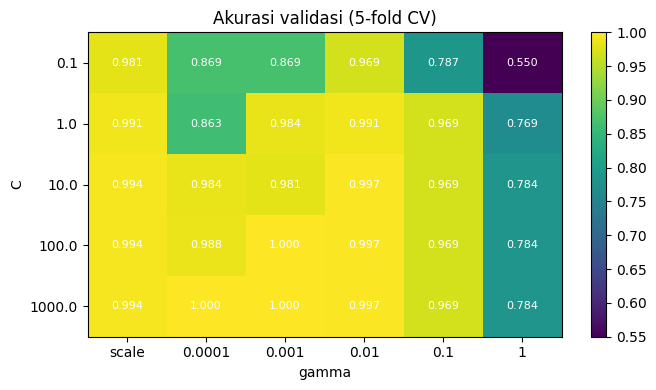

In [12]:
# Heatmap akurasi CV (C x gamma)
pivot = cv_res.pivot_table(index='param_svm__C', columns='param_svm__gamma', values='mean_test_score', aggfunc='first')
order = ['scale', 0.0001, 0.001, 0.01, 0.1, 1]
pivot = pivot[[c for c in order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('Akurasi validasi (5-fold CV)')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', color='w', fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Langkah 7 - Evaluasi Model Terbaik pada Data Uji

Tuned     | Train: 1.0000 | Test: 0.9875

              precision    recall  f1-score   support

       night     0.9756    1.0000    0.9877        40
         day     1.0000    0.9750    0.9873        40

    accuracy                         0.9875        80
   macro avg     0.9878    0.9875    0.9875        80
weighted avg     0.9878    0.9875    0.9875        80



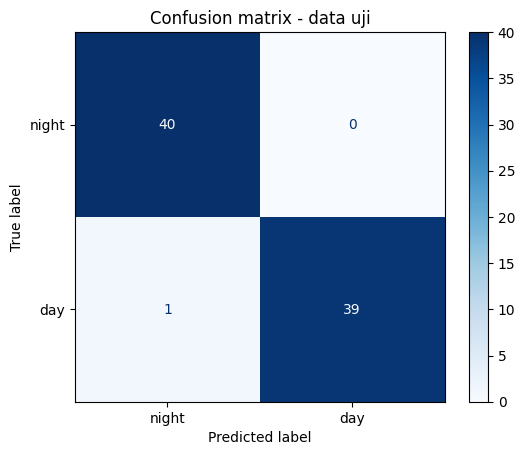

In [13]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

acc_tuned_train = accuracy_score(y_train, y_train_pred)
acc_tuned_test = accuracy_score(y_test, y_test_pred)

print(f'Tuned     | Train: {acc_tuned_train:.4f} | Test: {acc_tuned_test:.4f}\n')
print(classification_report(y_test, y_test_pred, target_names=['night', 'day'], digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['night', 'day'], cmap='Blues')
plt.title('Confusion matrix - data uji')
plt.show()

Jumlah salah prediksi: 1 dari 80


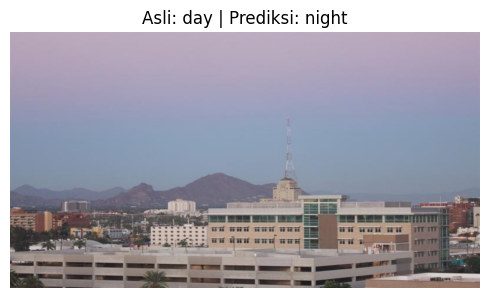

In [14]:
# Gambar yang salah diklasifikasi (jika ada)
# Urutan sampel data uji mengikuti train_test_split, jadi kita ulang split pada indeks
idx = np.arange(len(y))
_, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
wrong = idx_test[y_test_pred != y_test]
print(f'Jumlah salah prediksi: {len(wrong)} dari {len(idx_test)}')

if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(5 * len(wrong), 3.5), squeeze=False)
    for ax, i in zip(axes[0], wrong):
        pred = best_model.predict(X[i:i + 1])[0]
        ax.imshow(std_all[i][0])
        ax.set_title(f'Asli: {"day" if y[i] else "night"} | Prediksi: {"day" if pred else "night"}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Langkah 8 (Tambahan) - Perbandingan Jenis Histogram

Sebagai pembanding, tuning dengan grid yang sama dijalankan pada tiga jenis fitur histogram.

In [15]:
def hist_v(image, bins=32):
    v = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)[:, :, 2]
    h = cv2.calcHist([v], [0], None, [bins], [0, 256]).ravel()
    return h / h.sum()


def hist_rgb(image, bins=16):
    feats = []
    for ch in range(3):
        h = cv2.calcHist([image], [ch], None, [bins], [0, 256]).ravel()
        feats.append(h / h.sum())
    return np.concatenate(feats)


variants = {
    'Histogram V saja (32 fitur)': hist_v,
    'Histogram RGB (3 x 16 = 48 fitur)': hist_rgb,
    'Histogram HSV (16+16+32 = 64 fitur)': hsv_histogram,
}

rows = []
for name, fn in variants.items():
    Xv, yv = extract_features(std_all, fn)
    Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=0.20, random_state=RANDOM_STATE, stratify=yv)
    g = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1).fit(Xtr, ytr)
    rows.append({
        'Fitur': name,
        'C': g.best_params_['svm__C'],
        'gamma': g.best_params_['svm__gamma'],
        'Akurasi CV': g.best_score_,
        'Akurasi Test': accuracy_score(yte, g.predict(Xte)),
    })

pd.DataFrame(rows).round(4)

,Fitur,C,gamma,Akurasi CV,Akurasi Test
0,Histogram V saja (32 fitur),1,0.100,0.9906,0.9875
1,Histogram RGB (3 x 16 = 48 fitur),1000,0.001,0.9938,1.0000
2,Histogram HSV (16+16+32 = 64 fitur),100,0.001,1.0000,0.9875


## Ringkasan Akurasi

In [16]:
ringkasan = pd.DataFrame({
    'Model': [
        'SVM RBF default (C=1, gamma=scale)',
        f"SVM RBF tuned (C={grid.best_params_['svm__C']}, gamma={grid.best_params_['svm__gamma']})",
    ],
    'Akurasi Train': [acc_base_train, acc_tuned_train],
    'Akurasi CV (5-fold)': [np.nan, grid.best_score_],
    'Akurasi Test': [acc_base_test, acc_tuned_test],
})
ringkasan.round(4)

,Model,Akurasi Train,Akurasi CV (5-fold),Akurasi Test
0,"SVM RBF default (C=1, gamma=scale)",1.0,NaN,1.0000
1,"SVM RBF tuned (C=100, gamma=0.001)",1.0,1.0,0.9875


## Analisis

**Hasil akurasi (fitur histogram HSV 64 dimensi, split 80:20 = 320 latih / 80 uji):**

| Model | Akurasi Train | Akurasi CV (5-fold) | Akurasi Test |
|---|---|---|---|
| SVM RBF default (`C=1`, `gamma='scale'`) | 100 % | - | 100 % |
| SVM RBF tuned (`C=100`, `gamma=0.001`) | 100 % | 100 % | 98,75 % |

**Catatan:**
- Fitur histogram HSV sudah sangat memisahkan citra siang dan malam. Perbedaan paling jelas ada di kanal V (kecerahan): citra malam menumpuk di bin gelap, citra siang menyebar ke bin terang (lihat plot rata-rata histogram).
- Tuning **tidak menaikkan** akurasi data uji. Model tuned salah pada **1 dari 80** gambar (siang diprediksi malam), sedangkan model default benar semua. Selisih 1 gambar (1,25 poin) terlalu kecil untuk disebut perbedaan nyata pada 80 data uji.
- Banyak kombinasi `C` dan `gamma` menghasilkan akurasi CV 99-100 % (lihat tabel dan heatmap), jadi performa hampir datar terhadap pilihan hyperparameter pada data ini.
- Parameter terbaik dipilih lewat cross validation pada **data latih saja**, bukan dengan melihat akurasi data uji. Karena itu model tuned tetap dilaporkan apa adanya meskipun akurasi ujinya sedikit di bawah baseline.
- Perbandingan jenis histogram (V saja, RGB, HSV) menghasilkan akurasi uji 98,75-100 %, jadi pemilihan jenis histogram tidak banyak mengubah hasil. HSV memberi akurasi CV tertinggi (100 %).
- Batasan: dataset hanya 400 gambar sehingga hasil bisa bergeser sedikit bila `random_state` diganti.